# Industrial Subtype Classification

This notebook trains and evaluates a multiclass model for assigning Level-2 industrial building subtypes. It performs feature selection, hyperparameter optimization, class-imbalance handling, and final model evaluation.

**Input**
- Preprocessed industrial-subtype training, validation, and test data.
- Candidate machine-learning features.

**Output**
- Selected features for industrial subtype classification.
- Optimized multiclass models and evaluation results.
- Final trained industrial subtype classifier.

In [1]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l2a_ind_subtypes'

print(f"Training level: {LEVEL}")

Training level: l2a_ind_subtypes


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =====================================================================
# CELL 2 — Load Data for This Level
# =====================================================================
X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_raw.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_raw.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_raw.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
candidate_features = joblib.load(os.path.join(ML_DIR, 'candidate_features.pkl'))

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

n_classes = len(np.unique(y_train))
print(f"Classes : {classes}")
# print class count for training, test and validation sets
print("\nClass distribution in training set:")
print(np.bincount(y_train))
print("\nClass distribution in validation set:")
print(np.bincount(y_val))
print("\nClass distribution in test set:")
print(np.bincount(y_test))

print(f"CV Training Pool    : {X_train.shape[0]:,} rows")
print(f"Early Stop Monitor  : {X_val.shape[0]:,} rows (X_val)")
print(f"Holdout Test Set    : {X_test.shape[0]:,} rows (X_test)")


X_train : (116682, 110)
X_val   : (6931, 110)
X_test  : (13553, 110)
Classes : ['manufacturing' 'storage' 'utilities']

Class distribution in training set:
[10412 23270 83000]

Class distribution in validation set:
[ 630 1380 4921]

Class distribution in test set:
[1178 2816 9559]
CV Training Pool    : 116,682 rows
Early Stop Monitor  : 6,931 rows (X_val)
Holdout Test Set    : 13,553 rows (X_test)


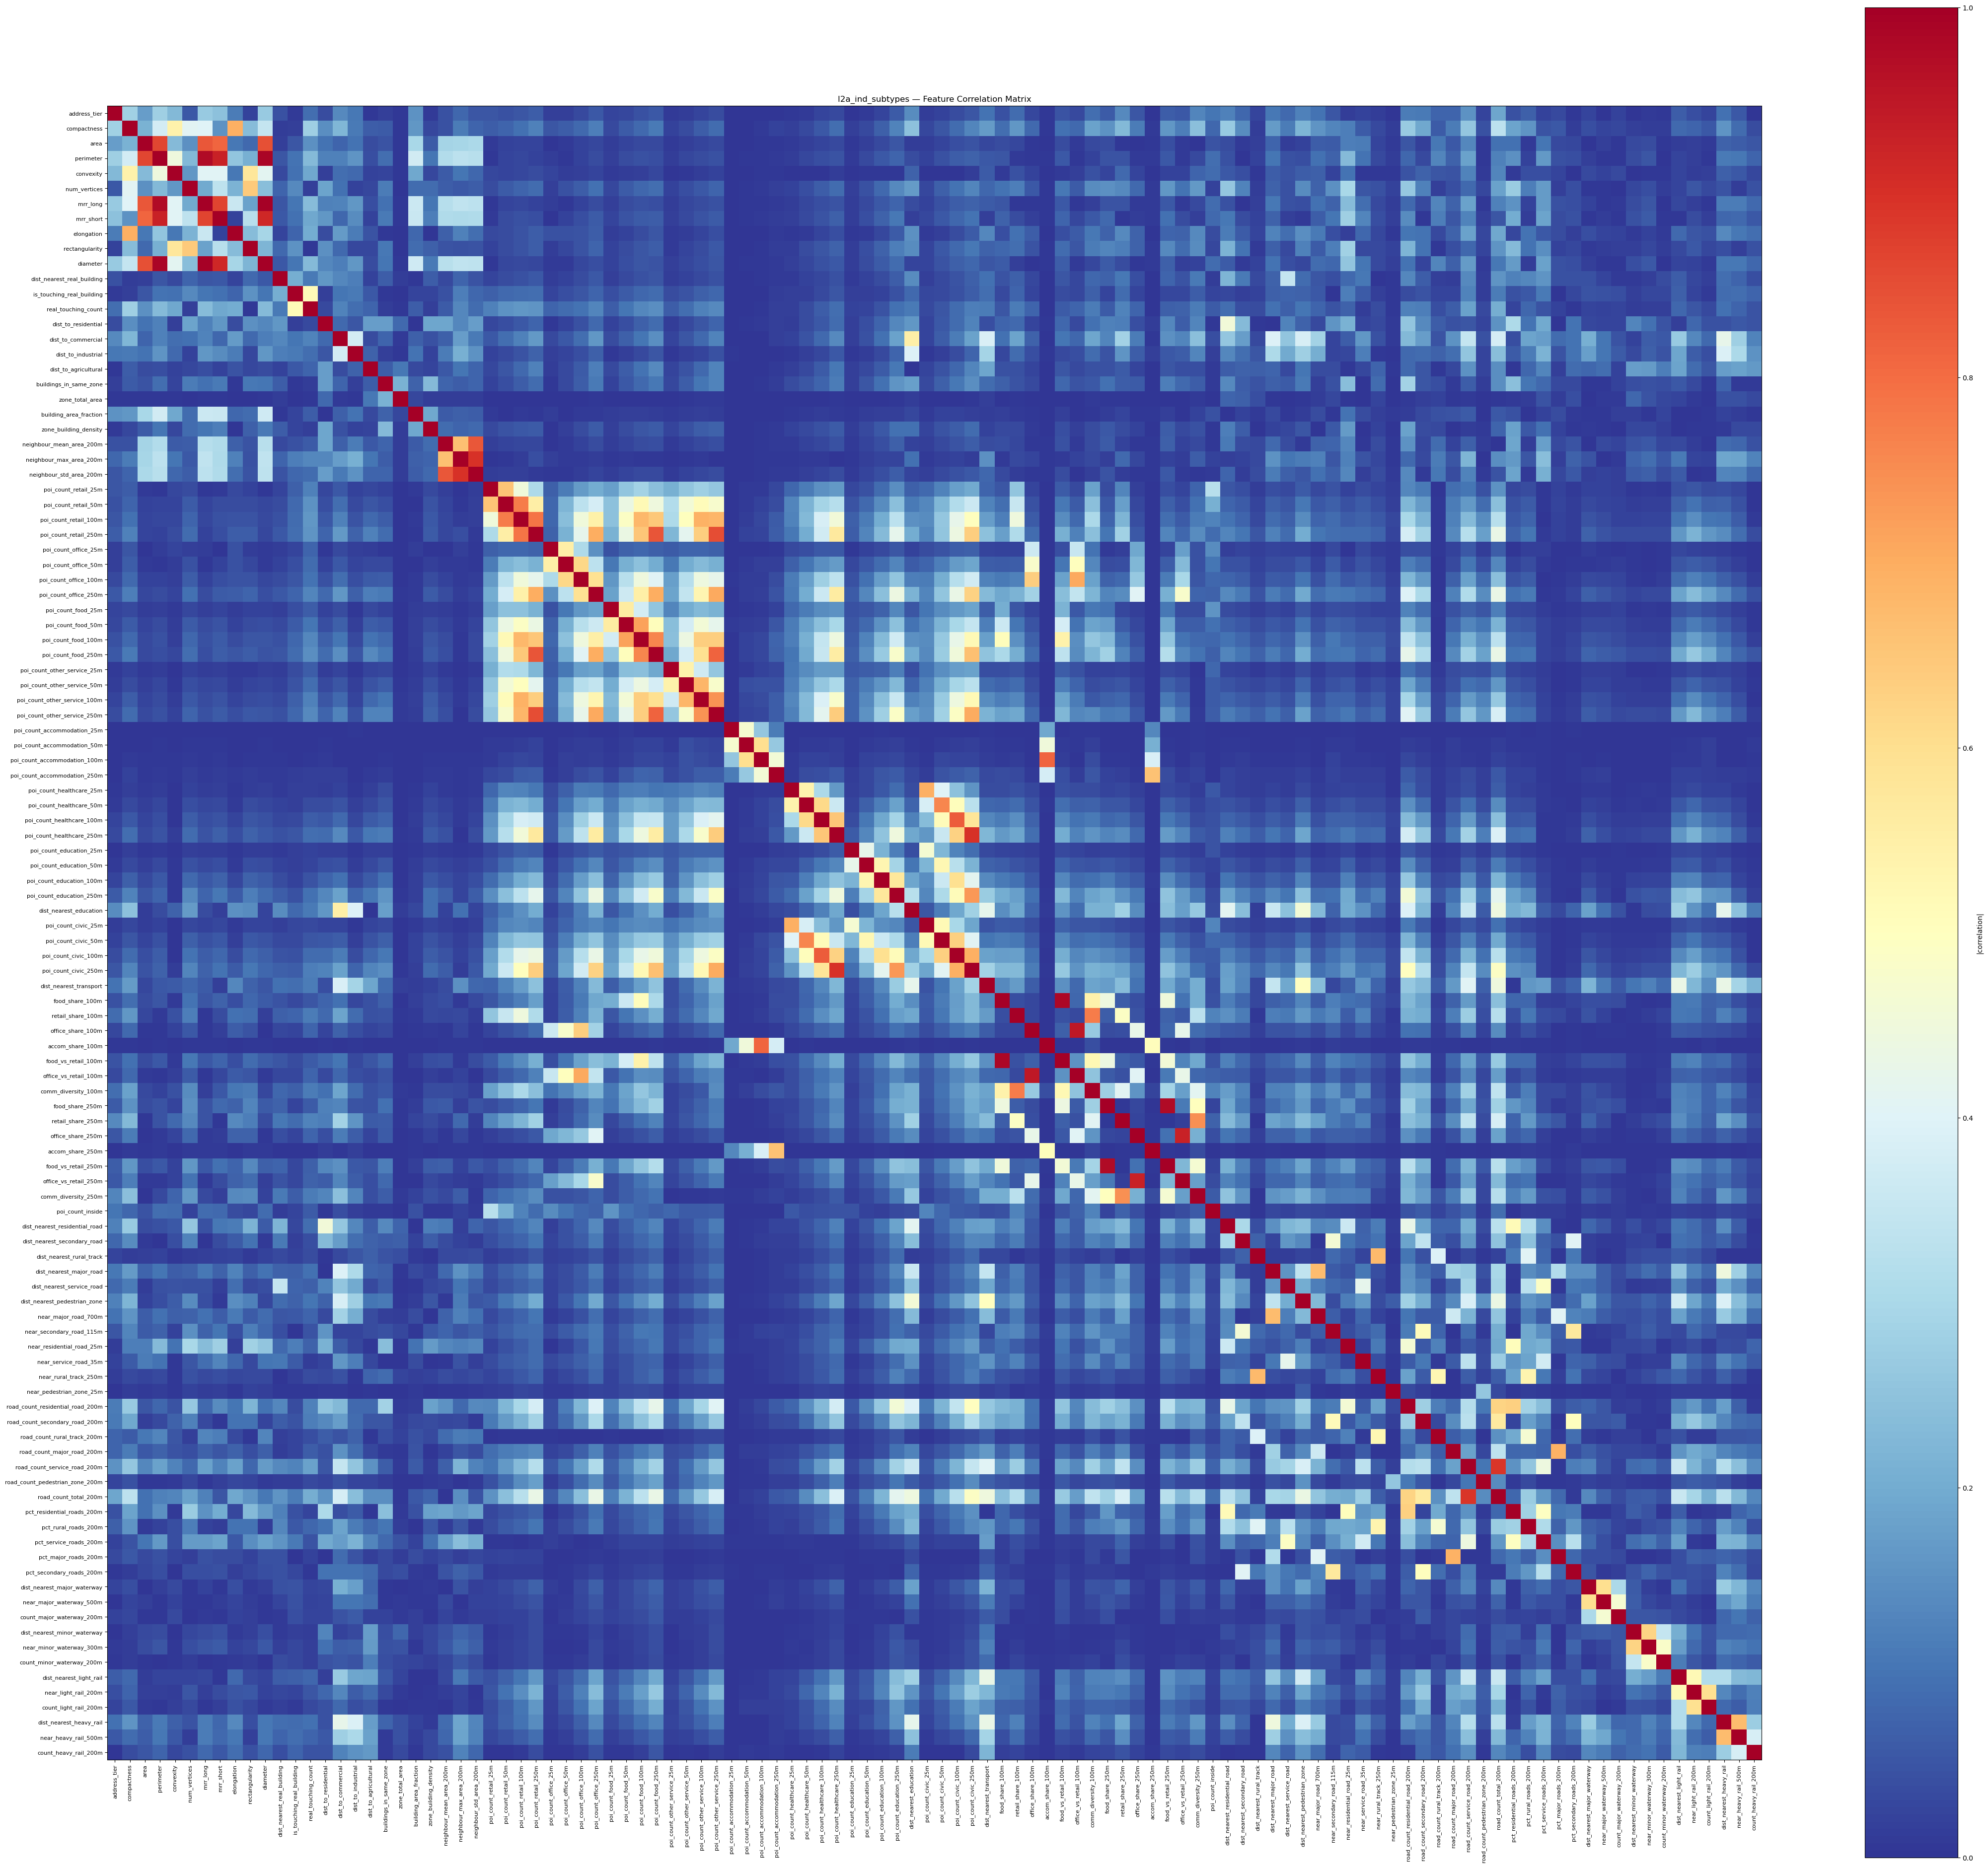

In [3]:
# Correlation Heatmap

corr_matrix = X_train[candidate_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(candidate_features)*0.4), max(6, len(candidate_features)*0.35)))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))
ax.set_xticklabels(candidate_features, rotation=90, fontsize=8)
ax.set_yticklabels(candidate_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Feature Correlation Matrix')
plt.tight_layout()
plt.show()


Class labels and their corresponding class names:
Class 0: manufacturing
Class 1: storage
Class 2: utilities
Excluded features (correlation <= 0.7 with all other features):
['address_tier', 'compactness', 'convexity', 'num_vertices', 'elongation', 'rectangularity', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'poi_count_retail_25m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_food_25m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_250m', 'poi_count_healthcare_25m', 'poi_count_education_25m', 'poi_count_education_50m', 'poi_count_education_100m', 'dist_nearest_education', 'poi_count_civic_25m', 'dist_nearest_transport', 'accom_share_250m', 'poi_coun

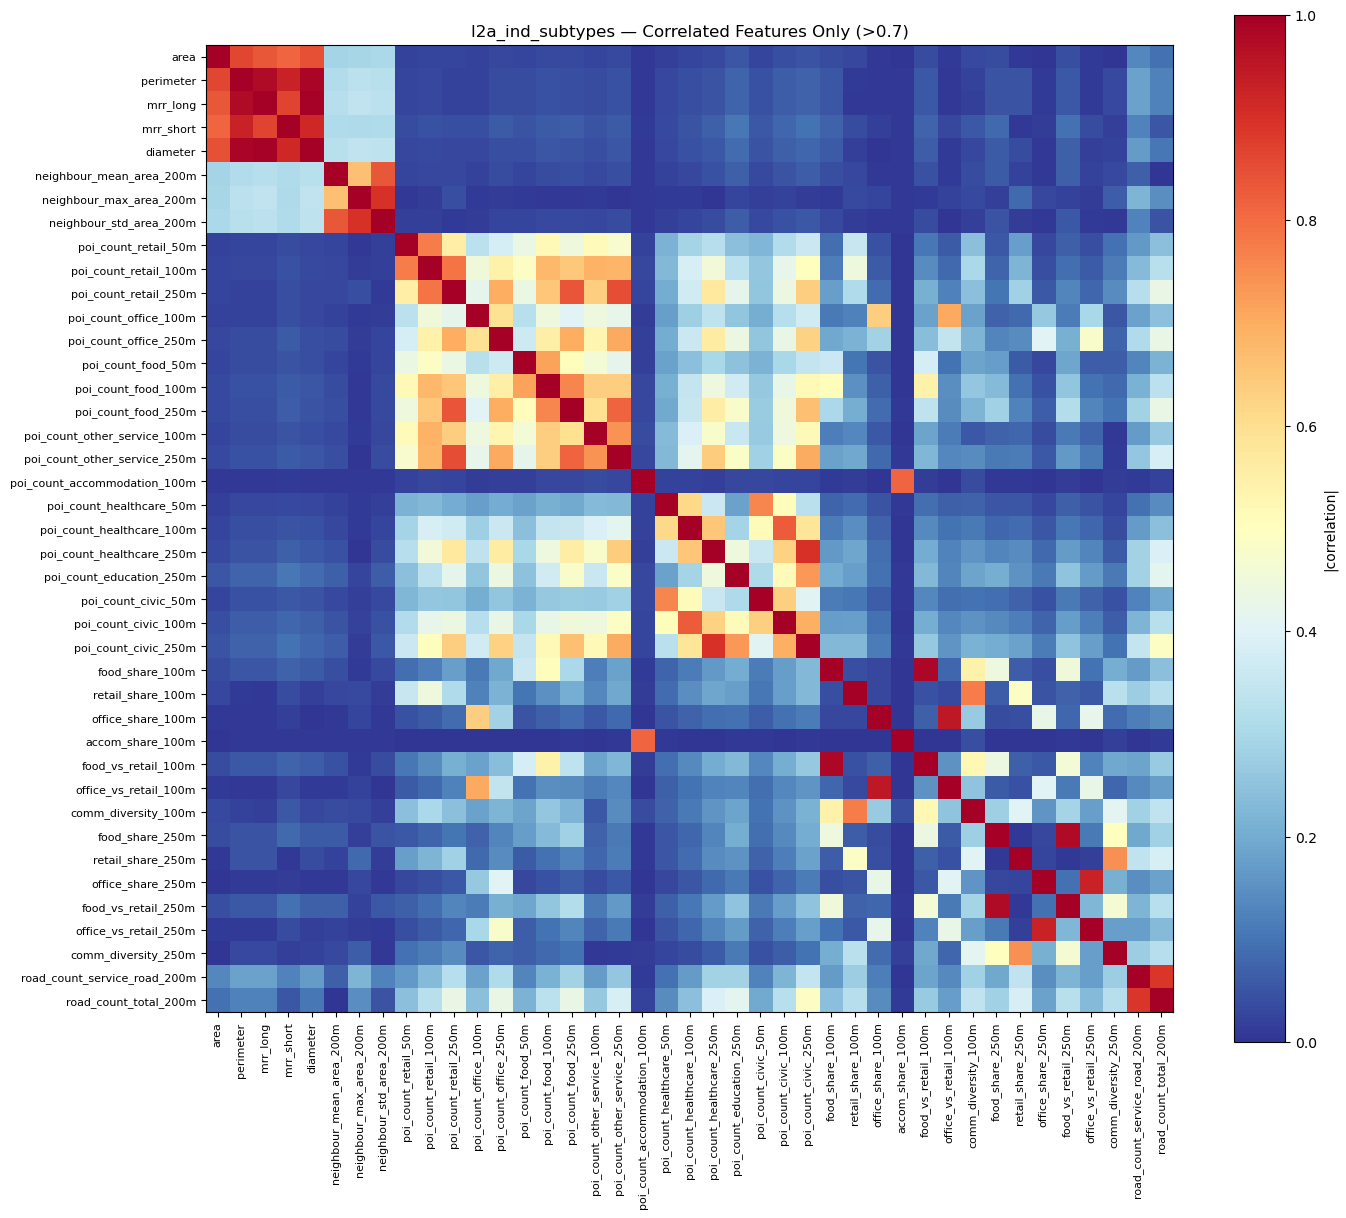

In [4]:
# too many features to view, only show features with correlation above a certain threshold
# check whicc class correspond sto posl_label 0 and 1
print("\nClass labels and their corresponding class names:")
for idx, class_name in enumerate(classes):
    print(f"Class {idx}: {class_name}")
    
FILTER_THRESHOLD = 0.7  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.9 with all other features):
['address_tier', 'compactness', 'area', 'convexity', 'num_vertices', 'elongation', 'rectangularity', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'neighbour_mean_area_200m', 'neighbour_max_area_200m', 'neighbour_std_area_200m', 'poi_count_retail_25m', 'poi_count_retail_50m', 'poi_count_retail_100m', 'poi_count_retail_250m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_office_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_other_service_100m', 'poi_count_other_service_250m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count

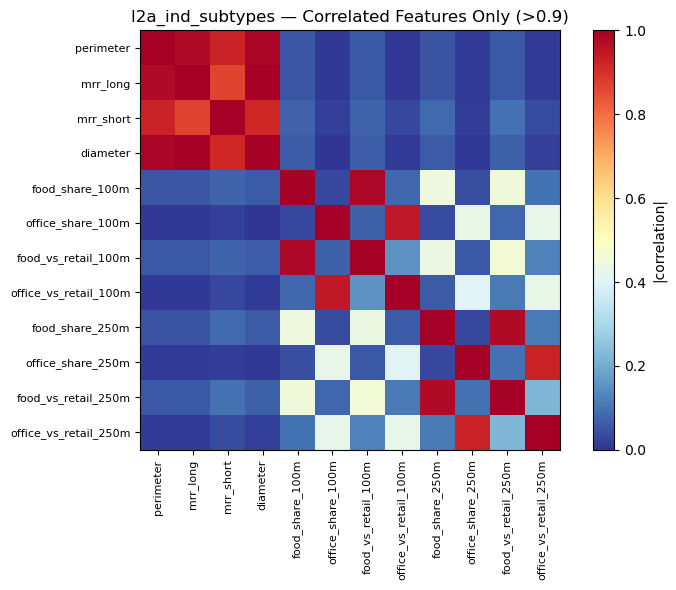

In [5]:

FILTER_THRESHOLD = 0.9  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Step 2b: Ranked List of Correlated Pairs
# ============================================================
CORR_THRESHOLD = 0.90  # just for flagging — nothing gets dropped in this cell

pairs = []
for i, c1 in enumerate(candidate_features):
    for c2 in candidate_features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if r > CORR_THRESHOLD:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f"{len(pairs_df)} pairs above {CORR_THRESHOLD}:\n")
pairs_df

9 pairs above 0.9:



,feature_1,feature_2,abs_corr
3,mrr_long,diameter,0.994
2,perimeter,diameter,0.987
5,food_share_100m,food_vs_retail_100m,0.981
0,perimeter,mrr_long,0.976
7,food_share_250m,food_vs_retail_250m,0.974
6,office_share_100m,office_vs_retail_100m,0.948
1,perimeter,mrr_short,0.926
8,office_share_250m,office_vs_retail_250m,0.926
4,mrr_short,diameter,0.915


In [7]:
# ============================================================
# Step 2c: Manual Correlation Drop List — EDIT THIS PER LEVEL
# ============================================================
# Look at pairs_df above and decide. Example — replace with your own calls:
CORR_DROP = ['perimeter', 'mrr_long', 'food_vs_retail_100m', 'food_vs_retail_250m',
'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m',
'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building'
]

kept_after_corr = [c for c in candidate_features if c not in CORR_DROP]
print(f"Dropped {len(CORR_DROP)} by hand: {CORR_DROP}")
print(f"Remaining: {len(kept_after_corr)} / {len(candidate_features)}")

Dropped 10 by hand: ['perimeter', 'mrr_long', 'food_vs_retail_100m', 'food_vs_retail_250m', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building']
Remaining: 103 / 110


Training until validation scores don't improve for 100 rounds
[500]	train's multi_logloss: 0.132853	val's multi_logloss: 0.210944
[1000]	train's multi_logloss: 0.0816974	val's multi_logloss: 0.198095
[1500]	train's multi_logloss: 0.0520789	val's multi_logloss: 0.19323
Early stopping, best iteration is:
[1591]	train's multi_logloss: 0.0480164	val's multi_logloss: 0.192913

BASELINE VAL PERFORMANCE — l2a_ind_subtypes  (103 features)
Macro F1    : 0.8425
Weighted F1 : 0.9241

               precision    recall  f1-score   support

manufacturing     0.8059    0.6524    0.7211       630
      storage     0.7997    0.8623    0.8298      1380
    utilities     0.9753    0.9776    0.9765      4921

     accuracy                         0.9251      6931
    macro avg     0.8603    0.8308    0.8425      6931
 weighted avg     0.9249    0.9251    0.9241      6931



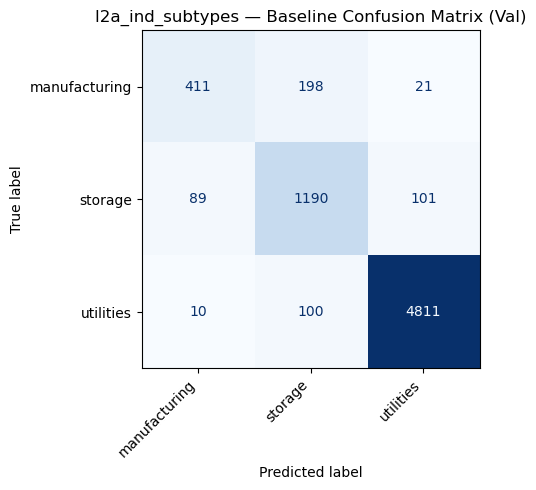

In [8]:
baseline_params = dict(
    n_estimators=2500, learning_rate=0.05, n_jobs=-1,
    random_state=42, verbosity=-1, importance_type='gain'
)
if n_classes == 2:
    lgb_baseline = lgb.LGBMClassifier(objective='binary', eval_metric='binary_logloss', **baseline_params)
else:
    lgb_baseline = lgb.LGBMClassifier(objective='multiclass', num_class=n_classes, eval_metric='multi_logloss', **baseline_params)

baseline_model = lgb_baseline

lgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=500),   # prints progress every 500 rounds
    ]
)
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

 # ── Val performance with the FULL kept_after_corr feature set ──
# This is your reference number — Cell J later compares the reduced
# feature set back against THIS, not against the full candidate pool,
# since correlation-dropped features were never meant to be kept anyway.
y_val_pred = baseline_model.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
baseline_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {baseline_macro_f1:.4f}")
print(f"Weighted F1 : {baseline_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# Confusion matrix — worth seeing now, before any pruning, as your reference point
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


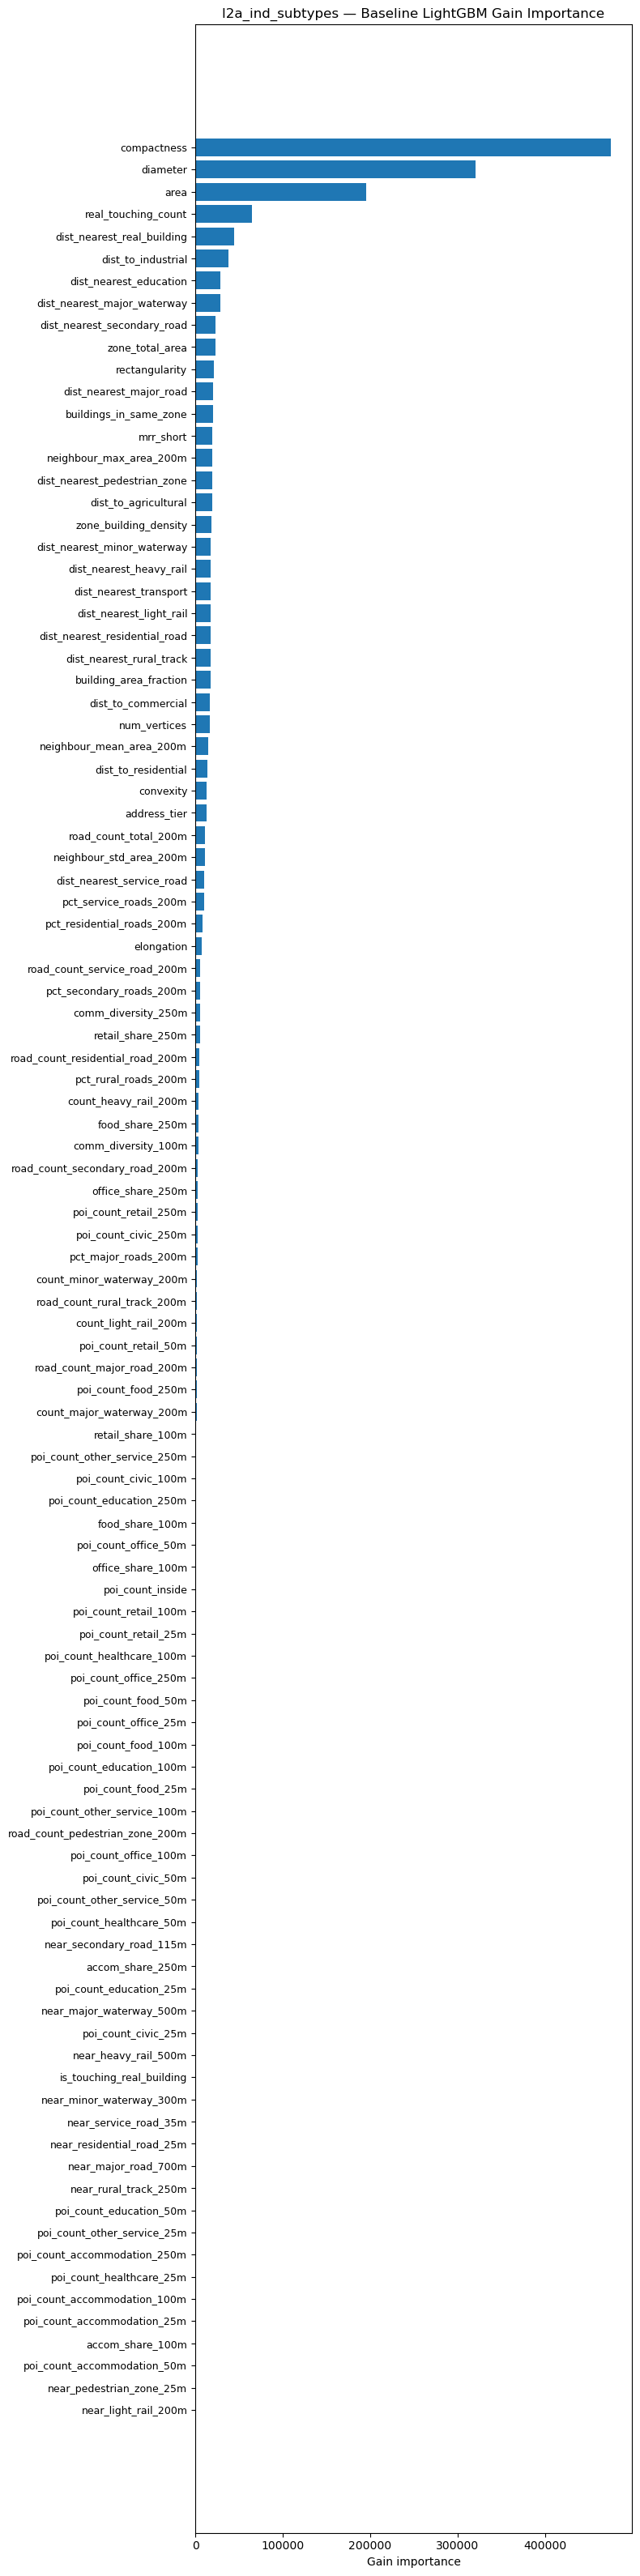

In [9]:
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(kept_after_corr)*0.3 + 1))
ax.barh(range(len(gain_importance)), gain_importance.values[::-1])
ax.set_yticks(range(len(gain_importance)))
ax.set_yticklabels(gain_importance.index[::-1], fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title(f'{LEVEL} — Baseline LightGBM Gain Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-mlogloss:0.73947	validation_1-mlogloss:0.74316
[500]	validation_0-mlogloss:0.15043	validation_1-mlogloss:0.21847
[1000]	validation_0-mlogloss:0.09894	validation_1-mlogloss:0.20298
[1500]	validation_0-mlogloss:0.06622	validation_1-mlogloss:0.19749
[1864]	validation_0-mlogloss:0.04927	validation_1-mlogloss:0.19642

Stopped at iteration: 1814

BASELINE VAL PERFORMANCE — l2a_ind_subtypes  (103 features)
Macro F1    : 0.8453
Weighted F1 : 0.9254

               precision    recall  f1-score   support

manufacturing     0.8167    0.6508    0.7244       630
      storage     0.8036    0.8688    0.8350      1380
    utilities     0.9749    0.9781    0.9765      4921

     accuracy                         0.9266      6931
    macro avg     0.8651    0.8326    0.8453      6931
 weighted avg     0.9264    0.9266    0.9254      6931



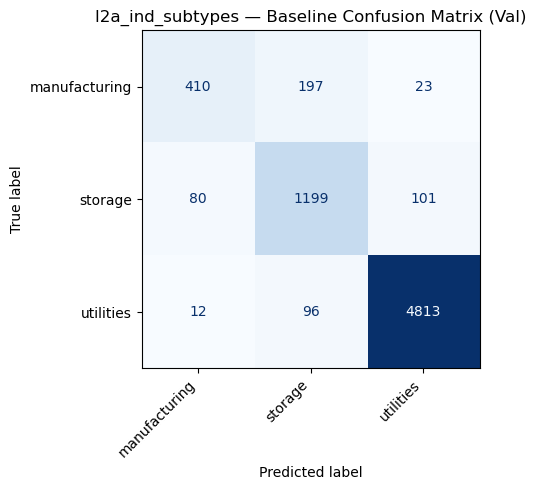

In [10]:
# ============================================================
# Step 4b: XGBoost Baseline — WITH Training Progress
# ============================================================
xgb_eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

xgb_params = dict(
    n_estimators=2500,
    learning_rate=0.05,
    n_jobs=-1, random_state=42,
    eval_metric=xgb_eval_metric,
    early_stopping_rounds=50,
)
if n_classes == 2:
    xgb_baseline = xgb.XGBClassifier(objective='binary:logistic', **xgb_params)
else:
    xgb_baseline = xgb.XGBClassifier(objective='multi:softprob', num_class=n_classes, **xgb_params)

xgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    verbose=500   # prints every 50 rounds, same as LightGBM's log_evaluation
)

print(f"\nStopped at iteration: {xgb_baseline.best_iteration}")
# ── Val performance with the FULL kept_after_corr feature set ──
# This is your reference number — Cell J later compares the reduced
# feature set back against THIS, not against the full candidate pool,
# since correlation-dropped features were never meant to be kept anyway.
y_val_pred = xgb_baseline.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
xgb_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
xgb_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {xgb_macro_f1:.4f}")
print(f"Weighted F1 : {xgb_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# Confusion matrix — worth seeing now, before any pruning, as your reference point
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




In [11]:
# ── XGBoost gain importance — compare ranking against LightGBM's ──
xgb_importance = pd.Series(
    xgb_baseline.get_booster().get_score(importance_type='gain'),
    name='xgb_gain'
)
# XGBoost uses f0, f1... as keys unless feature_names is set — map back
xgb_importance = xgb_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    'lightgbm_rank': gain_importance.rank(ascending=False),
    'xgboost_rank' : xgb_importance.reindex(gain_importance.index).rank(ascending=False)
}).sort_values('lightgbm_rank')
print("\nTop features — rank agreement between LightGBM and XGBoost:")
comparison.head(20)




Top features — rank agreement between LightGBM and XGBoost:


,lightgbm_rank,xgboost_rank
compactness,1.0,1.0
diameter,2.0,3.0
area,3.0,4.0
real_touching_count,4.0,2.0
dist_nearest_real_building,5.0,7.0
dist_to_industrial,6.0,10.0
dist_nearest_education,7.0,19.0
dist_nearest_major_waterway,8.0,24.0
dist_nearest_secondary_road,9.0,27.0
zone_total_area,10.0,16.0


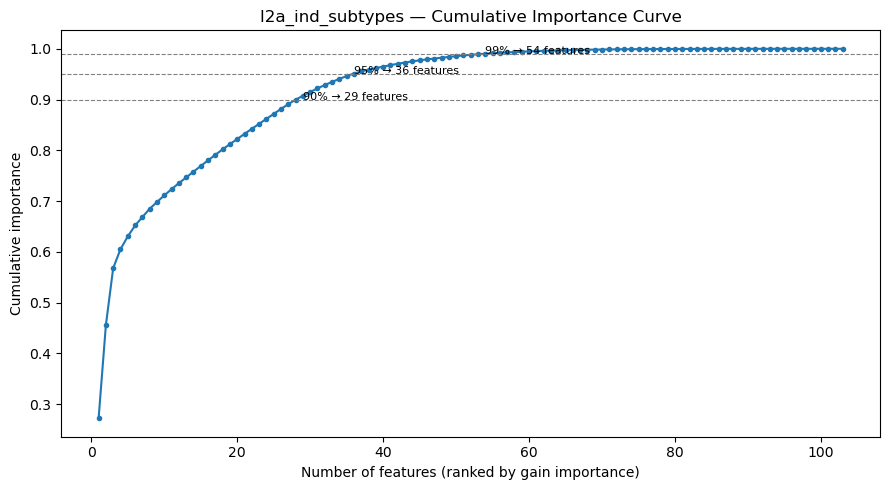

In [12]:
# ============================================================
# Step 6: Cumulative Importance — pick cutoff visually
# ============================================================
cum_importance = gain_importance.cumsum() / gain_importance.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, marker='o', markersize=3)
for pct in [0.90, 0.95, 0.99]:
    ax.axhline(pct, linestyle='--', color='gray', linewidth=0.8)
    n_at_pct = (cum_importance <= pct).sum() + 1
    ax.annotate(f'{int(pct*100)}% → {n_at_pct} features', xy=(n_at_pct, pct), fontsize=8)
ax.set_xlabel('Number of features (ranked by gain importance)')
ax.set_ylabel('Cumulative importance')
ax.set_title(f'{LEVEL} — Cumulative Importance Curve')
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Reconciling LightGBM vs XGBoost rank disagreement
# ============================================================
TOP_N = 55  # adjust based on your elbow plot from Cell H

lgb_top = set(comparison.sort_values('lightgbm_rank').head(TOP_N).index)
xgb_top = set(comparison.sort_values('xgboost_rank').head(TOP_N).index)

both_agree   = lgb_top & xgb_top   # strong keep — both models independently value these
lgb_only     = lgb_top - xgb_top   # LightGBM-favored — likely geometry/distance features
xgb_only     = xgb_top - lgb_top   # XGBoost-favored — likely POI/count features
neither      = set(comparison.index) - lgb_top - xgb_top   # both models agree these are weak

print(f"Both models rank in top {TOP_N}: {len(both_agree)}")
print(sorted(both_agree))
print(f"\nLightGBM-only top {TOP_N} (geometry-leaning?): {len(lgb_only)}")
print(sorted(lgb_only))
print(f"\nXGBoost-only top {TOP_N} (POI-count-leaning?): {len(xgb_only)}")
print(sorted(xgb_only))
print(f"\nBoth models agree these are weak — safe drop candidates: {len(neither)}")
print(sorted(neither))

union_selection = both_agree | lgb_only | xgb_only
selected_features = sorted(union_selection)  # convert to list for indexing
print(f"\nUnion selection: {len(union_selection)} features")

Both models rank in top 55: 41
['address_tier', 'area', 'building_area_fraction', 'buildings_in_same_zone', 'comm_diversity_100m', 'comm_diversity_250m', 'compactness', 'convexity', 'count_heavy_rail_200m', 'count_light_rail_200m', 'diameter', 'dist_nearest_education', 'dist_nearest_heavy_rail', 'dist_nearest_light_rail', 'dist_nearest_major_road', 'dist_nearest_major_waterway', 'dist_nearest_minor_waterway', 'dist_nearest_pedestrian_zone', 'dist_nearest_real_building', 'dist_nearest_residential_road', 'dist_nearest_rural_track', 'dist_nearest_secondary_road', 'dist_nearest_transport', 'dist_to_agricultural', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_residential', 'mrr_short', 'neighbour_max_area_200m', 'neighbour_mean_area_200m', 'neighbour_std_area_200m', 'num_vertices', 'office_share_250m', 'poi_count_civic_250m', 'poi_count_retail_50m', 'real_touching_count', 'rectangularity', 'retail_share_250m', 'road_count_total_200m', 'zone_building_density', 'zone_total_area']

Ligh

In [14]:
# ============================================================
# Step 8: Before/After Sanity Check
# ============================================================

model_full = type(baseline_model)(**baseline_model.get_params())
model_full.fit(X_train[candidate_features], y_train)
pred_full = model_full.predict(X_val[candidate_features])

model_reduced = type(baseline_model)(**baseline_model.get_params())
model_reduced.fit(X_train[selected_features], y_train)
pred_reduced = model_reduced.predict(X_val[selected_features])

avg = 'macro' if n_classes > 2 else 'binary'
f1_full    = f1_score(y_val, pred_full, average=avg)
f1_reduced = f1_score(y_val, pred_reduced, average=avg)

print(f"F1 (val) — full pool ({len(candidate_features)} feats)     : {f1_full:.4f}")
print(f"F1 (val) — selected  ({len(selected_features)} feats)      : {f1_reduced:.4f}")
print(f"Difference: {f1_reduced - f1_full:+.4f}")

F1 (val) — full pool (110 feats)     : 0.8525
F1 (val) — selected  (69 feats)      : 0.8525
Difference: -0.0000


In [15]:
# Try a more aggressive cut and see if it still holds
for n in [30, 40, 50, 60, 73]:
    trial_features = list(gain_importance.index[:n])
    model_trial = type(baseline_model)(**baseline_model.get_params())
    model_trial.fit(X_train[trial_features], y_train)
    pred_trial = model_trial.predict(X_val[trial_features])
    f1_trial = f1_score(y_val, pred_trial, average='macro' if n_classes > 2 else 'binary')
    print(f"N={n:>3}: F1={f1_trial:.4f}  (diff from full: {f1_trial - f1_full:+.4f})")

N= 30: F1=0.8461  (diff from full: -0.0064)
N= 40: F1=0.8512  (diff from full: -0.0013)
N= 50: F1=0.8522  (diff from full: -0.0003)
N= 60: F1=0.8503  (diff from full: -0.0022)
N= 73: F1=0.8535  (diff from full: +0.0010)


In [16]:
joblib.dump(selected_features, os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))

# --- Step 4: reduce all splits, THEN convert to numpy for XGBoost/LightGBM ---
feature_cols = selected_features   # keeps downstream cells (importance plots) working unchanged
X_train = X_train[selected_features].values
X_val   = X_val[selected_features].values
X_test  = X_test[selected_features].values

In [17]:


def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = model.predict(X_sp).astype(int)
        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        
        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()}")
        print(f"  Macro F1           : {macro_f1:.4f}")
        print(f"  Weighted F1        : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test 
    y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results

all_results = {}

# ============================================================
# Multi-Objective Optuna — Setup
# ============================================================
n_classes = len(classes)
minority_class_idx = pd.Series(y_train).value_counts().idxmin()
print(f"Minority class: {classes[minority_class_idx]} (index {minority_class_idx})")
print(f"Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)")

def get_sample_weights(y, minority_boost=1.0):
    base_weights = compute_sample_weight(class_weight='balanced', y=y)
    class_counts_local = pd.Series(y).value_counts()
    minority_idx = class_counts_local.idxmin()
    boost_mask = (y == minority_idx)
    weights = base_weights.copy()
    weights[boost_mask] *= minority_boost
    return weights

Minority class: manufacturing (index 0)
Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)


In [19]:
N_TRIALS  = 50
n_classes = len(classes)

# Compute once outside objectives — same weights reused across trials
# Single split against X_val — CV runs separately in run_final_cv_audit

print(f"Running Optuna across {N_TRIALS} trials for {n_classes} classes...")

def objective_lightgbm(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights = get_sample_weights(y_train, minority_boost=minority_boost)

    params = {
        'objective'        : 'multiclass',
        'num_class'        : n_classes,
        'metric'           : 'multi_logloss',
        'boosting_type'    : 'gbdt',
        'n_estimators'     : 2000,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'max_depth'        : -1,
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 300),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'n_jobs'           : -1,
        'random_state'     : 42,
        'verbosity'        : -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1    = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]

    # Store the full breakdown so you can inspect any trial later without retraining
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1


def objective_xgboost(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights = get_sample_weights(y_train, minority_boost=minority_boost)
    
    params = {
        'objective'            : 'multi:softprob',
        'num_class'            : n_classes,
        'eval_metric'          : 'mlogloss',
        'n_estimators'         : 2000,
        'learning_rate'        : trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'max_depth'            : trial.suggest_int('max_depth', 4, 10),
        'subsample'            : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'     : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'alpha'                : trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda'               : trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'gamma'                : trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        'min_child_weight'     : trial.suggest_int('min_child_weight', 1, 60, log=True),
        'tree_method'          : 'hist',
        'early_stopping_rounds': 30,
        'n_jobs'               : -1,
        'random_state'         : 42
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1    = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1


print("Optimizing LightGBM (multi-objective)...")
study_lgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_lgb_multi.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\nLightGBM Pareto front: {len(study_lgb_multi.best_trials)} non-dominated trials")

print("\nOptimizing XGBoost (multi-objective)...")
study_xgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_xgb_multi.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nXGBoost Pareto front : {len(study_xgb_multi.best_trials)} non-dominated trials")

Running Optuna across 50 trials for 3 classes...
Optimizing LightGBM (multi-objective)...


  0%|                                                                                                                                                                                                                                                                                              | 0/50 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [3:26:37<00:00, 247.95s/it]



LightGBM Pareto front: 1 non-dominated trials

Optimizing XGBoost (multi-objective)...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [56:13<00:00, 67.47s/it]


XGBoost Pareto front : 1 non-dominated trials


Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 24
	params: {'minority_boost': 1.222670645629654, 'learning_rate': 0.03627591750435285, 'num_leaves': 108, 'min_child_samples': 87, 'subsample': 0.9823033100495097, 'colsample_bytree': 0.6274622374550001, 'reg_alpha': 0.812614905785513, 'reg_lambda': 0.04220291735677803}
	values: [0.8591761711695005, 0.760586319218241]
Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 17
	params: {'minority_boost': 3.284377329072911, 'learning_rate': 0.08834583208666721, 'max_depth': 10, 'subsample': 0.6400611118465375, 'colsample_bytree': 0.6302745499236129, 'alpha': 0.26657813410668024, 'lambda': 0.00223895270998283, 'gamma': 0.177320591047123, 'min_child_weight': 2}
	values: [0.8602834377403252, 0.7648]
Minority F1 values across all trials:
count    50.000000
mean      0.742650
std       0.009823
min       0.717300
25%       0.738866
50%       0.744222
75%       0.748521
max       0.760586
dty

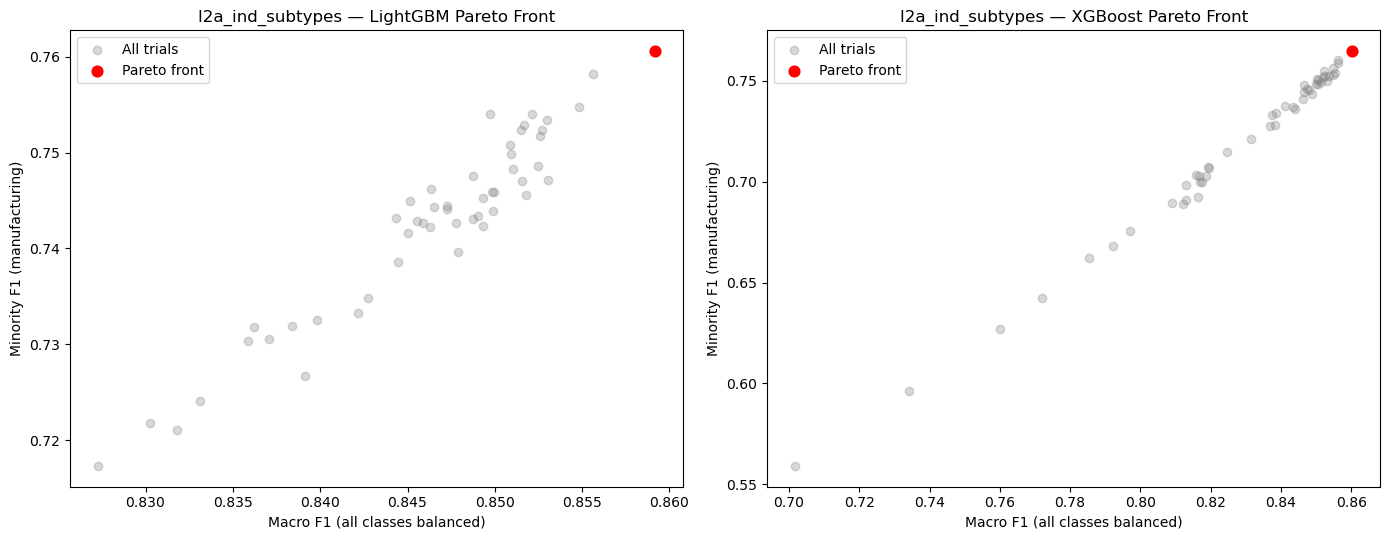

In [20]:
print(f"Number of trials on the Pareto front: {len(study_lgb_multi.best_trials)}")

trial_with_highest_score_lgb = max(study_lgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_lgb.number}")
print(f"\tparams: {trial_with_highest_score_lgb.params}")
print(f"\tvalues: {trial_with_highest_score_lgb.values}")

print(f"Number of trials on the Pareto front: {len(study_xgb_multi.best_trials)}")

trial_with_highest_score_xgb = max(study_xgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_xgb.number}")
print(f"\tparams: {trial_with_highest_score_xgb.params}")
print(f"\tvalues: {trial_with_highest_score_xgb.values}")

# Check which of the three explanations applies
print("Minority F1 values across all trials:")
minority_f1_values = [t.values[1] for t in study_lgb_multi.trials if t.values is not None]
print(pd.Series(minority_f1_values).describe())
print(f"\nUnique minority-F1 values: {len(set(round(v, 4) for v in minority_f1_values))}")

print("\nminority_boost values tried:")
boosts = [t.params['minority_boost'] for t in study_lgb_multi.trials]
print(pd.Series(boosts).describe())

# Check which of the three explanations applies
print("Minority F1 values across all trials:")
minority_f1_values_xgb = [t.values[1] for t in study_xgb_multi.trials if t.values is not None]
print(pd.Series(minority_f1_values_xgb).describe())
print(f"\nUnique minority-F1 values: {len(set(round(v, 4) for v in minority_f1_values_xgb))}")

print("\nminority_boost values tried:")
boosts_xgb = [t.params['minority_boost'] for t in study_xgb_multi.trials]
print(pd.Series(boosts_xgb).describe())
# ============================================================
# Plot the Pareto Front
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, study, name in [(axes[0], study_lgb_multi, 'LightGBM'), (axes[1], study_xgb_multi, 'XGBoost')]:
    all_macro    = [t.values[0] for t in study.trials if t.values is not None]
    all_minority = [t.values[1] for t in study.trials if t.values is not None]
    pareto_macro    = [t.values[0] for t in study.best_trials]
    pareto_minority = [t.values[1] for t in study.best_trials]

    ax.scatter(all_macro, all_minority, alpha=0.3, color='gray', label='All trials')
    ax.scatter(pareto_macro, pareto_minority, color='red', s=60, label='Pareto front', zorder=5)

    # Sort pareto points to draw a connecting line
    pareto_pts = sorted(zip(pareto_macro, pareto_minority))
    ax.plot(*zip(*pareto_pts), color='red', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Macro F1 (all classes balanced)')
    ax.set_ylabel(f'Minority F1 ({classes[minority_class_idx]})')
    ax.set_title(f'{LEVEL} — {name} Pareto Front')
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Select a trial from the Pareto front — stated selection rule
# ============================================================
# Rule: maximize minority F1, subject to macro F1 not dropping more than
# MAX_MACRO_DROP below the single best macro-F1 trial on the front.
MAX_MACRO_DROP = 0.01

best_macro_on_front = max(t.values[0] for t in study_lgb_multi.best_trials)
eligible_trials = [
    t for t in study_lgb_multi.best_trials
    if t.values[0] >= best_macro_on_front - MAX_MACRO_DROP
]
selected_trial = max(eligible_trials, key=lambda t: t.values[1])  # highest minority F1 among eligible

print(f"Selected LightGBM trial #{selected_trial.number}")
print(f"  Macro F1    : {selected_trial.values[0]:.4f}  (best on front: {best_macro_on_front:.4f})")
print(f"  Minority F1 : {selected_trial.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial.params}")

best_lgb_params = selected_trial.params


# ============================================================
# Select a trial from the XGBoost Pareto front — same rule as LightGBM
# ============================================================
best_macro_on_front_xgb = max(t.values[0] for t in study_xgb_multi.best_trials)
eligible_trials_xgb = [
    t for t in study_xgb_multi.best_trials
    if t.values[0] >= best_macro_on_front_xgb - MAX_MACRO_DROP
]
selected_trial_xgb = max(eligible_trials_xgb, key=lambda t: t.values[1])

print(f"Selected XGBoost trial #{selected_trial_xgb.number}")
print(f"  Macro F1    : {selected_trial_xgb.values[0]:.4f}  (best on front: {best_macro_on_front_xgb:.4f})")
print(f"  Minority F1 : {selected_trial_xgb.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial_xgb.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial_xgb.params}")

best_xgb_params = selected_trial_xgb.params

Selected LightGBM trial #24
  Macro F1    : 0.8592  (best on front: 0.8592)
  Minority F1 : 0.7606
  Per-class F1: {'manufacturing': 0.760586319218241, 'storage': 0.8398601398601399, 'utilities': 0.9770820544301207}
  Params      : {'minority_boost': 1.222670645629654, 'learning_rate': 0.03627591750435285, 'num_leaves': 108, 'min_child_samples': 87, 'subsample': 0.9823033100495097, 'colsample_bytree': 0.6274622374550001, 'reg_alpha': 0.812614905785513, 'reg_lambda': 0.04220291735677803}
Selected XGBoost trial #17
  Macro F1    : 0.8603  (best on front: 0.8603)
  Minority F1 : 0.7648
  Per-class F1: {'manufacturing': 0.7648, 'storage': 0.8393489030431706, 'utilities': 0.976701410177805}
  Params      : {'minority_boost': 3.284377329072911, 'learning_rate': 0.08834583208666721, 'max_depth': 10, 'subsample': 0.6400611118465375, 'colsample_bytree': 0.6302745499236129, 'alpha': 0.26657813410668024, 'lambda': 0.00223895270998283, 'gamma': 0.177320591047123, 'min_child_weight': 2}


In [22]:
# ============================================================
# Train Final Model with Selected Pareto-Front Params
# ============================================================
final_minority_boost_lgb = best_lgb_params.pop('minority_boost', None)  # not a model param, remove before passing to LGBMClassifier
if final_minority_boost_lgb is None:
    raise ValueError("Selected LightGBM trial does not have 'minority_boost' parameter.")
final_sample_weights_lgb = get_sample_weights(y_train, minority_boost=final_minority_boost_lgb)

final_minority_boost_xgb = best_xgb_params.pop('minority_boost', None)  # not a model param
if final_minority_boost_xgb is None:
    raise ValueError("Selected XGBoost trial does not have 'minority_boost' parameter.")
final_sample_weights_xgb = get_sample_weights(y_train, minority_boost=final_minority_boost_xgb)



In [23]:

# save the best hyperparameters for reference
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'w') as f:
    json.dump({'lightgbm': best_lgb_params, 'xgboost': best_xgb_params}, f, indent=4)

 # Allow full tree growth for LightGB
def run_final_cv_audit(model_name, best_params, X_data, y_data):
    print(f"\n{'='*60}\nFINAL 5-FOLD CV AUDIT: {model_name.upper()}\n{'='*60}")
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    macro_f1_scores    = []
    weighted_f1_scores = []
    oof_preds          = np.zeros(len(y_data))
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_data, y_data), 1):
        X_tr, y_tr = X_data[train_idx], y_data[train_idx]
        X_v,  y_v  = X_data[val_idx],   y_data[val_idx]
        
        # Always compute weights per fold for both models
        fold_weights = get_sample_weights(y_tr, minority_boost=final_minority_boost_lgb if model_name == 'lightgbm' else final_minority_boost_xgb)
        
        if model_name == 'lightgbm':
            model = lgb.LGBMClassifier(
                objective='multiclass', num_class=n_classes, metric='multi_logloss',
                boosting_type='gbdt', n_estimators=10000,
                importance_type='gain', n_jobs=-1, random_state=42, verbosity=-1,
                **best_params
                # class_weight removed — sample_weight used instead
            )
            model.fit(
                X_tr, y_tr,
                sample_weight=fold_weights,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(50, verbose=False)]
            )
            
        elif model_name == 'xgboost':
            model = xgb.XGBClassifier(
                objective='multi:softprob', num_class=n_classes, eval_metric='mlogloss',
                n_estimators=10000, tree_method='hist', importance_type='gain',
                early_stopping_rounds=50, n_jobs=-1, random_state=42,
                **best_params
            )
            model.fit(
                X_tr, y_tr,
                sample_weight=fold_weights,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

        preds          = model.predict(X_v)
        oof_preds[val_idx] = preds
        
        fold_macro    = f1_score(y_v, preds, average='macro')
        fold_weighted = f1_score(y_v, preds, average='weighted')
        macro_f1_scores.append(fold_macro)
        weighted_f1_scores.append(fold_weighted)
        
        print(f"Fold {fold} | Macro F1: {fold_macro:.4f} | Weighted F1: {fold_weighted:.4f}")

    print(f"\n--- OOF CV SUMMARY ({model_name.upper()}) ---")
    print(f"Mean Macro F1    : {np.mean(macro_f1_scores):.4f} ± {np.std(macro_f1_scores):.4f}")
    print(f"Mean Weighted F1 : {np.mean(weighted_f1_scores):.4f} ± {np.std(weighted_f1_scores):.4f}")
    
    print(f"\nFull OOF Classification Report for {model_name.upper()}:")
    print(classification_report(y_data, oof_preds, target_names=classes, digits=4))
    
    return oof_preds

oof_preds_lgb = run_final_cv_audit('lightgbm', best_lgb_params, X_train, y_train)
oof_preds_xgb = run_final_cv_audit('xgboost', best_xgb_params, X_train, y_train)


FINAL 5-FOLD CV AUDIT: LIGHTGBM
Fold 1 | Macro F1: 0.8571 | Weighted F1: 0.9282
Fold 2 | Macro F1: 0.8598 | Weighted F1: 0.9293
Fold 3 | Macro F1: 0.8605 | Weighted F1: 0.9300
Fold 4 | Macro F1: 0.8586 | Weighted F1: 0.9300
Fold 5 | Macro F1: 0.8625 | Weighted F1: 0.9302

--- OOF CV SUMMARY (LIGHTGBM) ---
Mean Macro F1    : 0.8597 ± 0.0018
Mean Weighted F1 : 0.9296 ± 0.0007

Full OOF Classification Report for LIGHTGBM:
               precision    recall  f1-score   support

manufacturing     0.7723    0.7525    0.7623     10412
      storage     0.8152    0.8696    0.8415     23270
    utilities     0.9829    0.9677    0.9752     83000

     accuracy                         0.9289    116682
    macro avg     0.8568    0.8633    0.8597    116682
 weighted avg     0.9307    0.9289    0.9296    116682


FINAL 5-FOLD CV AUDIT: XGBOOST
Fold 1 | Macro F1: 0.8541 | Weighted F1: 0.9268
Fold 2 | Macro F1: 0.8608 | Weighted F1: 0.9305
Fold 3 | Macro F1: 0.8556 | Weighted F1: 0.9274
Fold 4 | Mac

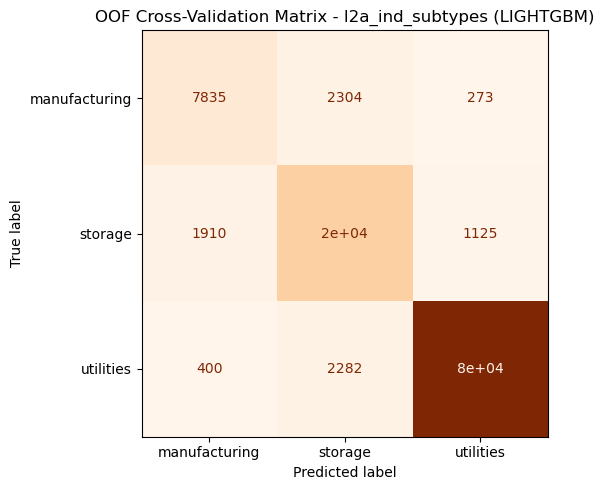

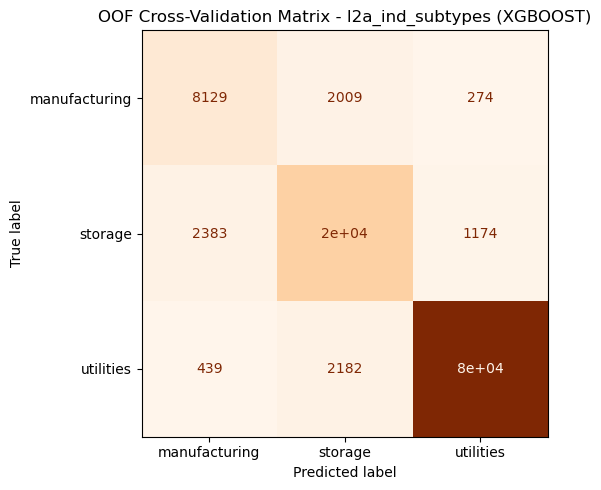

In [24]:
cm = confusion_matrix(y_train, oof_preds_lgb) 
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'OOF Cross-Validation Matrix - {LEVEL} (LIGHTGBM)')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_train, oof_preds_xgb) 
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'OOF Cross-Validation Matrix - {LEVEL} (XGBOOST)')
plt.tight_layout()
plt.show()

In [25]:
print(f"\n{'='*60}\nTRAINING UNIFIED MODELS ON FULL X_TRAIN\n{'='*60}")
trained_models = {}

# Compute once on full training data — used by both models
full_train_sample_weights_lgb = get_sample_weights(y_train, minority_boost=final_minority_boost_lgb)  # same boost for both models
full_train_sample_weights_xgb = get_sample_weights(y_train, minority_boost=final_minority_boost_xgb)

# --- Train LightGBM ---
print("Training unified LightGBM...")
lgb_params = {
    'objective': 'multiclass', 'num_class': n_classes, 'metric': 'multi_logloss', 
    'boosting_type': 'gbdt', 'n_estimators': 15000, 
    'importance_type': 'gain', 'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    **best_lgb_params
    # class_weight removed — sample_weight passed in fit() instead
}
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(
    X_train, y_train,
    sample_weight=full_train_sample_weights_lgb,   # added
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
trained_models['lightgbm'] = model_lgb

# --- Train XGBoost ---
print("Training unified XGBoost...")
xgb_params = {
    'objective': 'multi:softprob', 'num_class': n_classes, 'eval_metric': 'mlogloss',
    'n_estimators': 15000, 'tree_method': 'hist', 'importance_type': 'gain',
    'early_stopping_rounds': 100, 'n_jobs': -1, 'random_state': 42,
    **best_xgb_params
}
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(
    X_train, y_train,
    sample_weight=full_train_sample_weights_xgb,
    eval_set=[(X_val, y_val)],
    verbose=False
)
trained_models['xgboost'] = model_xgb

print("\nUnified base models trained and stored in `trained_models`!")


TRAINING UNIFIED MODELS ON FULL X_TRAIN
Training unified LightGBM...
[200]	valid_0's multi_logloss: 0.243805
[400]	valid_0's multi_logloss: 0.211991
[600]	valid_0's multi_logloss: 0.197843
[800]	valid_0's multi_logloss: 0.191655
[1000]	valid_0's multi_logloss: 0.188974
[1200]	valid_0's multi_logloss: 0.188915
Training unified XGBoost...

Unified base models trained and stored in `trained_models`!



FINAL HOLDOUT TEST SET EVALUATION

lightgbm — VAL
  Macro F1           : 0.8602
  Weighted F1        : 0.9306
               precision    recall  f1-score   support

manufacturing     0.7836    0.7413    0.7618       630
      storage     0.8134    0.8717    0.8416      1380
    utilities     0.9837    0.9707    0.9772      4921

     accuracy                         0.9302      6931
    macro avg     0.8602    0.8612    0.8602      6931
 weighted avg     0.9316    0.9302    0.9306      6931


lightgbm — TEST
  Macro F1           : 0.8699
  Weighted F1        : 0.9340
               precision    recall  f1-score   support

manufacturing     0.7842    0.7683    0.7762      1178
      storage     0.8337    0.8828    0.8575      2816
    utilities     0.9833    0.9687    0.9760      9559

     accuracy                         0.9334     13553
    macro avg     0.8671    0.8733    0.8699     13553
 weighted avg     0.9349    0.9334    0.9340     13553



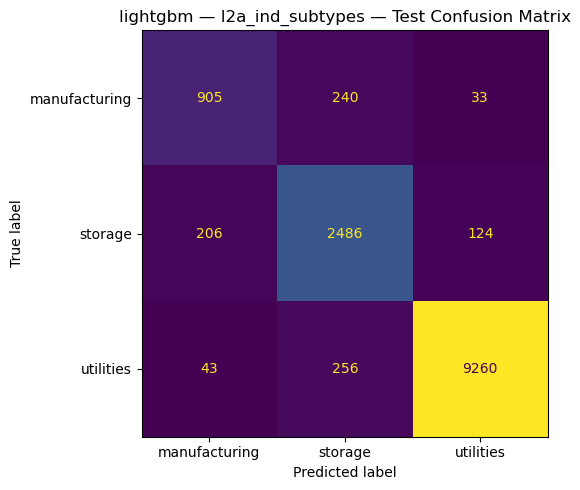


xgboost — VAL
  Macro F1           : 0.8603
  Weighted F1        : 0.9301
               precision    recall  f1-score   support

manufacturing     0.7710    0.7587    0.7648       630
      storage     0.8202    0.8594    0.8393      1380
    utilities     0.9823    0.9711    0.9767      4921

     accuracy                         0.9296      6931
    macro avg     0.8578    0.8631    0.8603      6931
 weighted avg     0.9308    0.9296    0.9301      6931


xgboost — TEST
  Macro F1           : 0.8669
  Weighted F1        : 0.9328
               precision    recall  f1-score   support

manufacturing     0.7578    0.7861    0.7717      1178
      storage     0.8432    0.8629    0.8529      2816
    utilities     0.9819    0.9706    0.9762      9559

     accuracy                         0.9322     13553
    macro avg     0.8609    0.8732    0.8669     13553
 weighted avg     0.9336    0.9322    0.9328     13553



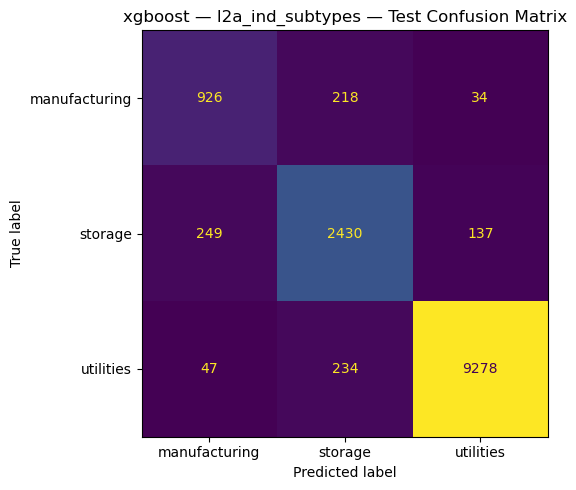


MODEL COMPARISON — l2a_ind_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.8699        0.9340
xgboost                  0.8669        0.9328


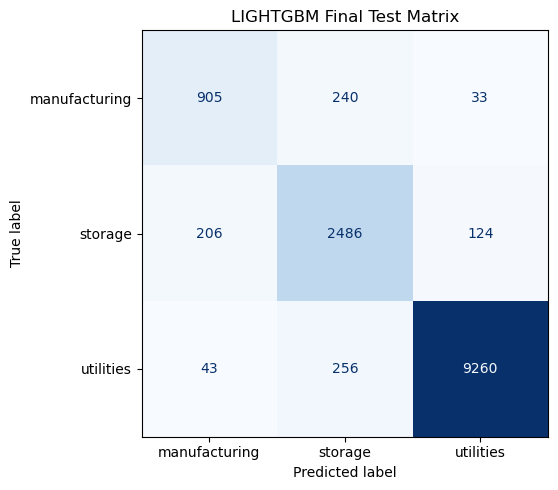

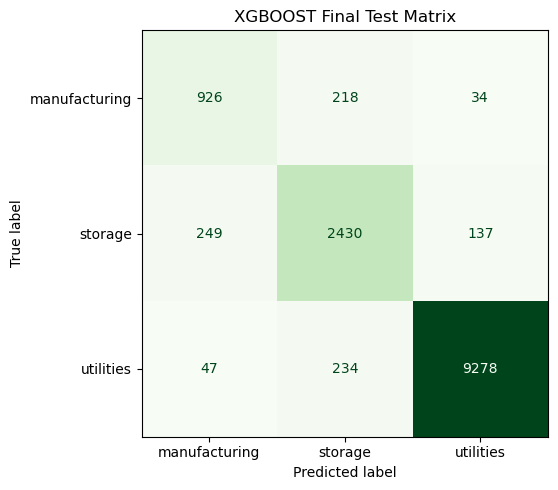

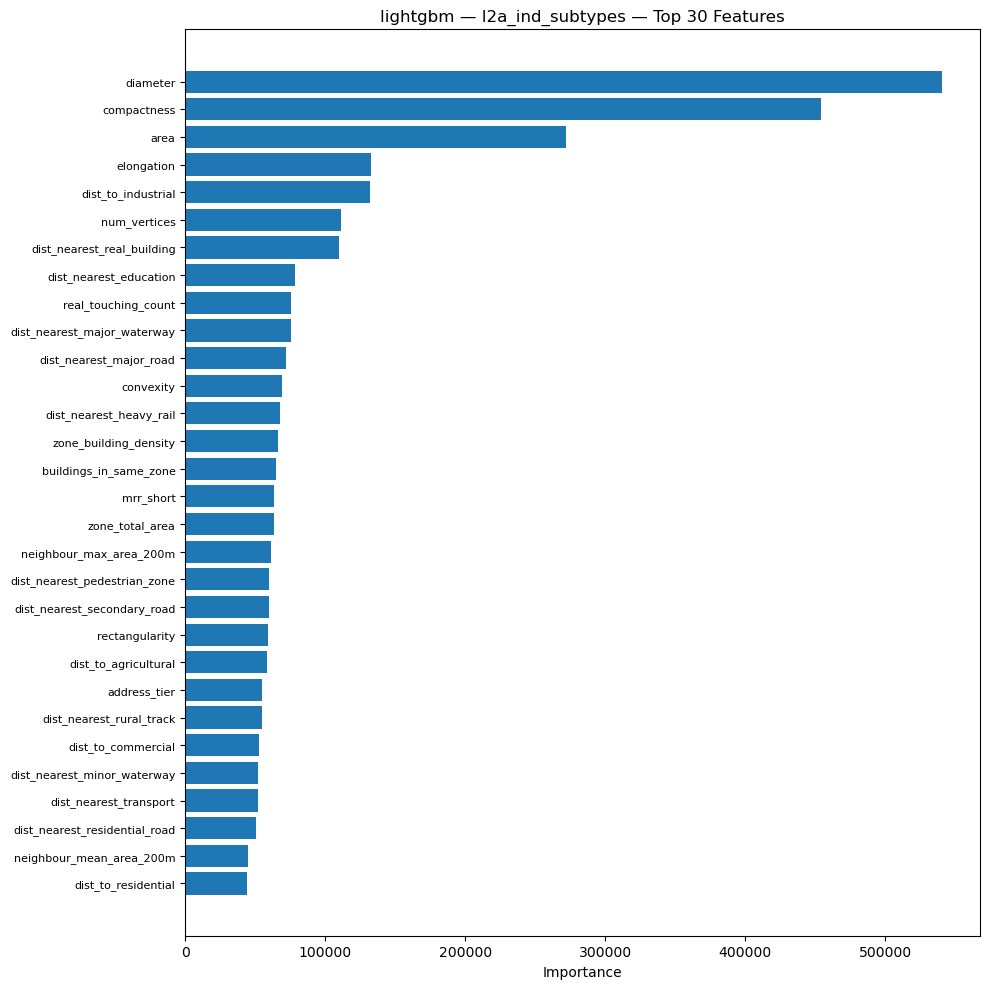

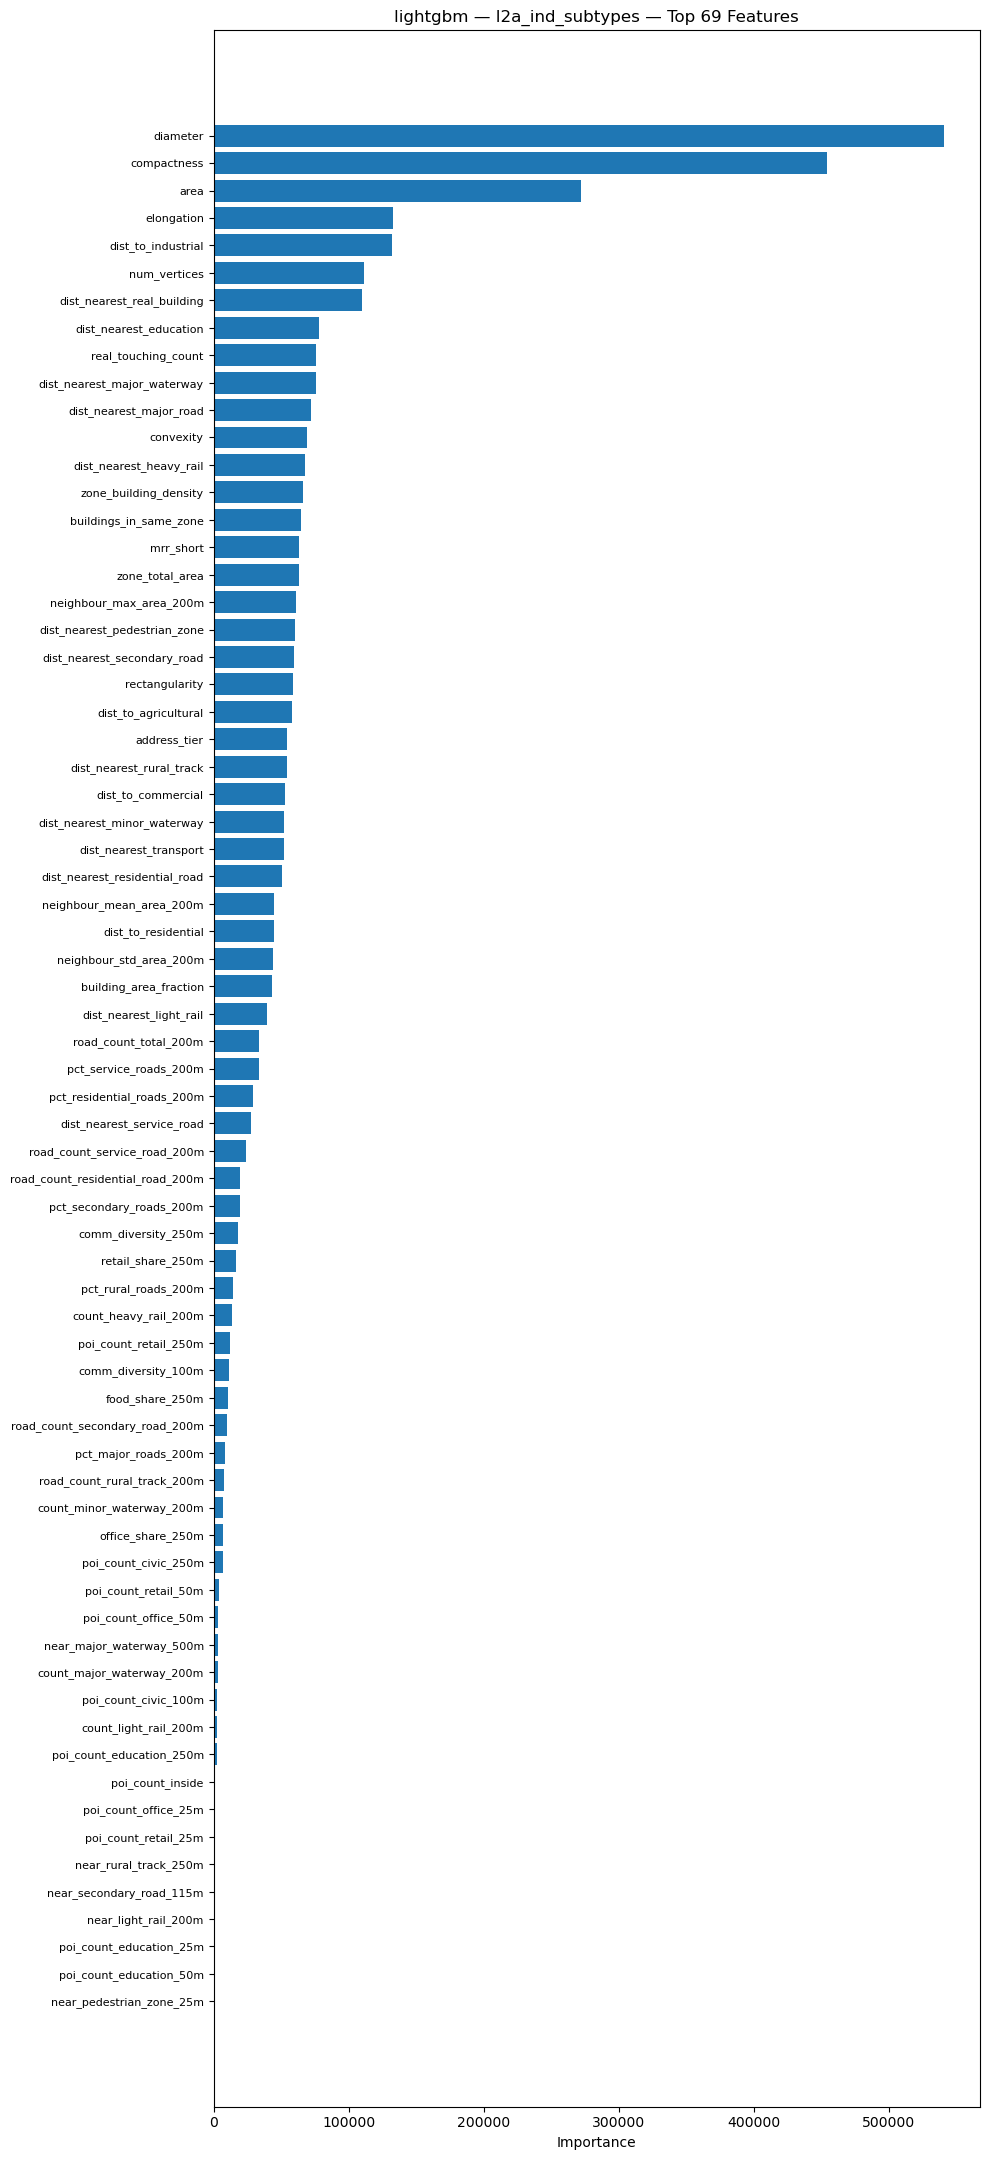

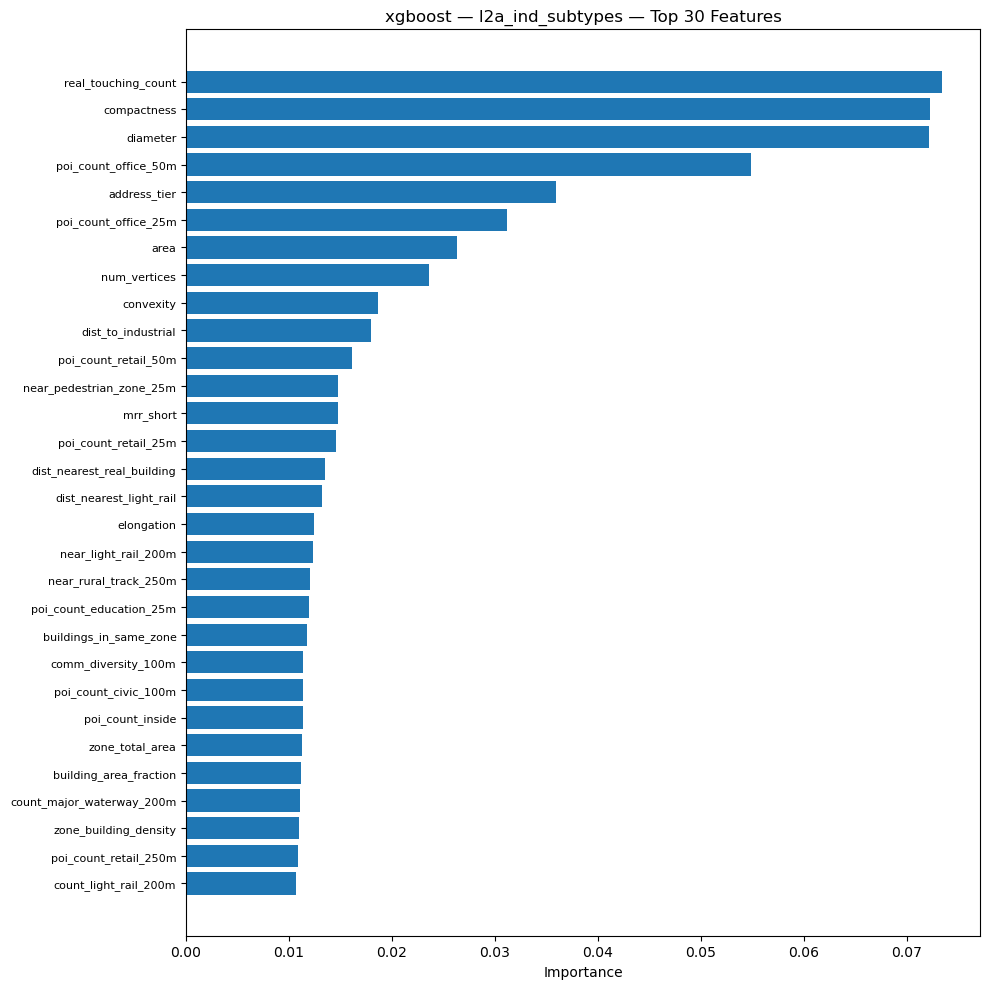

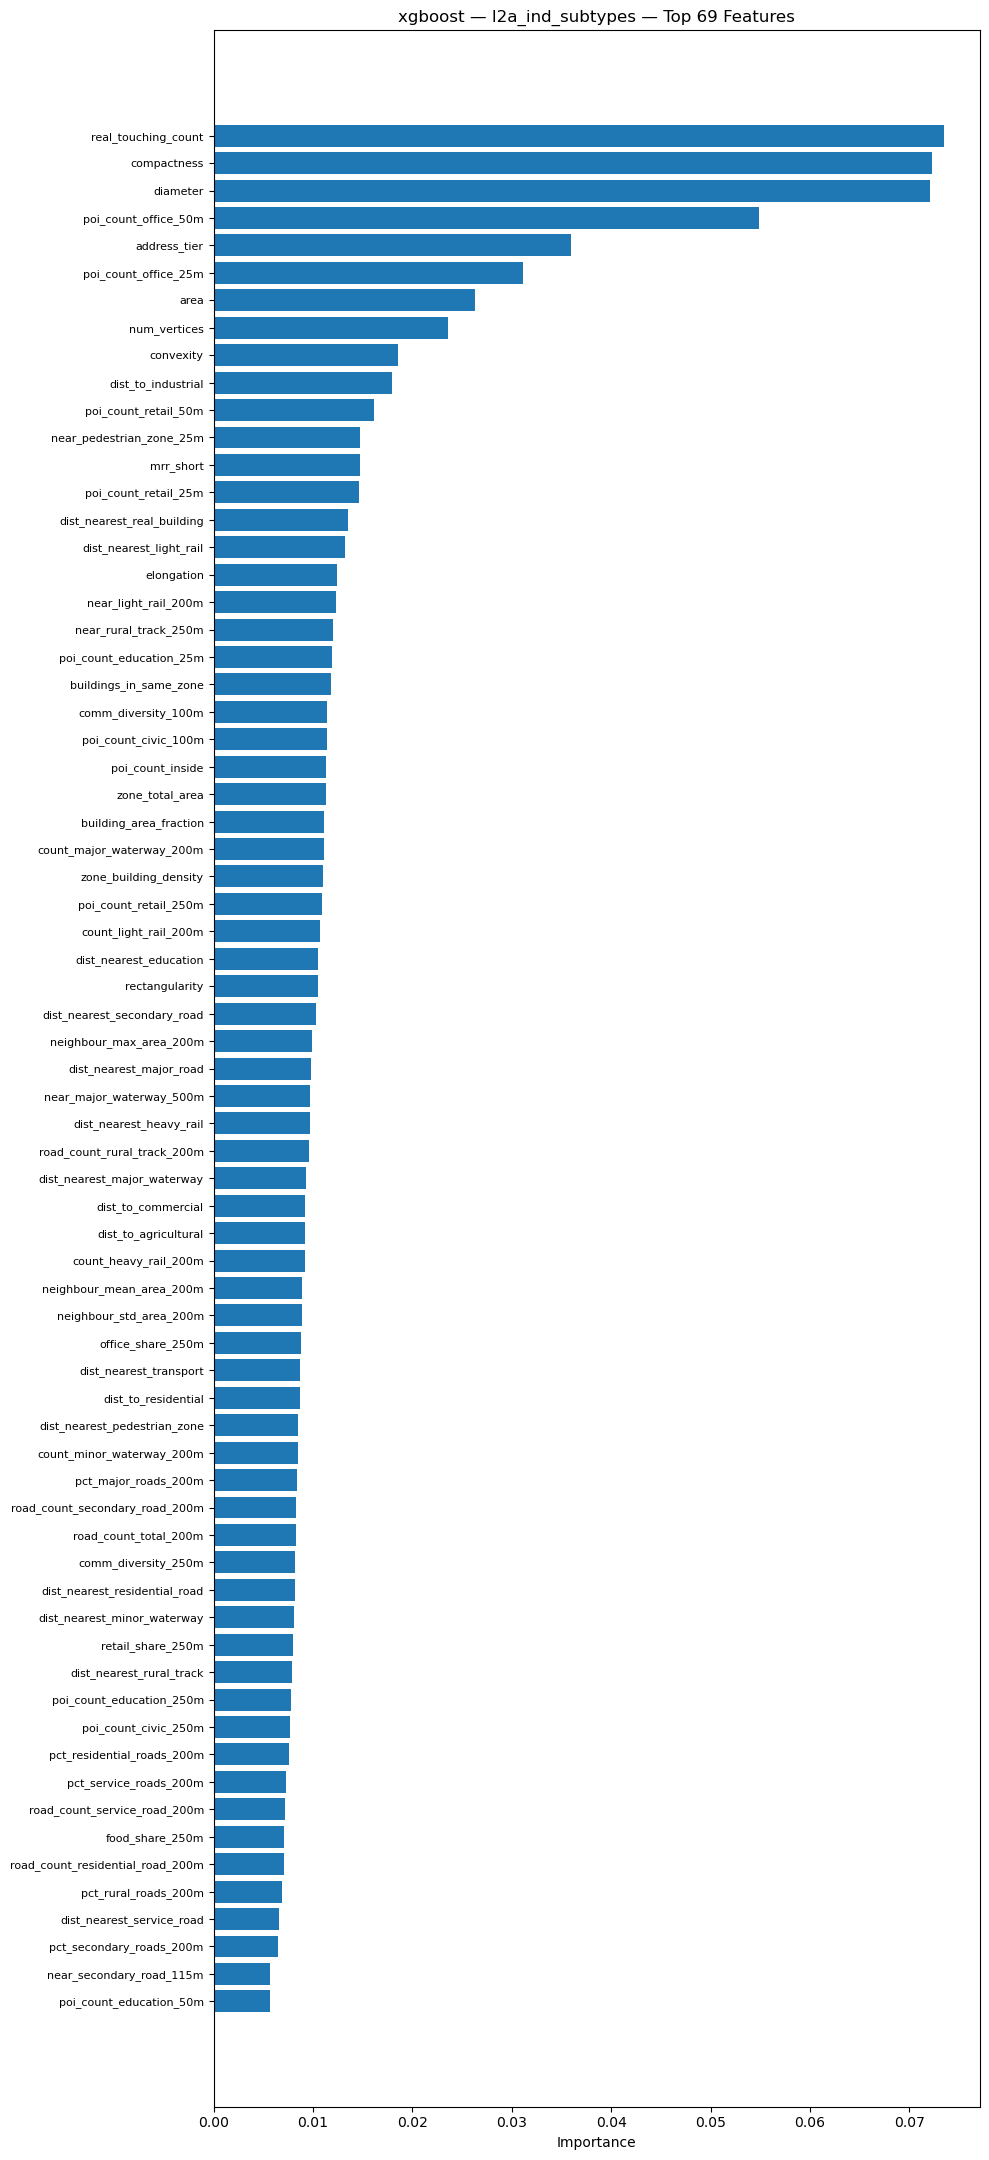

In [26]:
print(f"\n{'='*60}\nFINAL HOLDOUT TEST SET EVALUATION\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL)

print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)
for model_name, res in all_results.items():
    print(f"{model_name:<20} {res['test']['macro_f1']:>10.4f} {res['test']['weighted_f1']:>13.4f}")

# 1. Print Confusion Matrices on Unseen Test Set
for model_name, model in trained_models.items():
    test_preds = model.predict(X_test).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    cmap_color = 'Blues' if model_name == 'lightgbm' else 'Greens'
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap=cmap_color, colorbar=False)
    ax.set_title(f'{model_name.upper()} Final Test Matrix')
    plt.tight_layout()
    plt.show()

# 2. Print Feature Importances
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        idx  = np.argsort(imp)[::-1][:top_n]
        fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
        ax.barh(range(top_n), imp[idx][::-1])
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
        ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [27]:
# =====================================================================
# CELL 7 — Compare All Models on This Level
# =====================================================================
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l2a_ind_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.8699        0.9340
xgboost                  0.8669        0.9328

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l2a_ind_subtypes_results.json


In [28]:
# =====================================================================
# FINAL PRODUCTION ROLLOUT (100% DATA - FIXED ITERATIONS)
# =====================================================================
BEST_MODEL_NAME = 'lightgbm'  # Change to 'xgboost' if XGBoost performed better

print(f"Preparing final production model: {BEST_MODEL_NAME.upper()} on 100% of data")

# 1. Combine ALL data splits (100% of available data)
X_production_train = np.vstack([X_train, X_val, X_test])
y_production_train = np.concatenate([y_train, y_val, y_test])

# 2. Recompute balanced weights on the entire dataset
prod_weights = get_sample_weights(y_production_train, minority_boost=final_minority_boost_lgb if BEST_MODEL_NAME == 'lightgbm' else final_minority_boost_xgb)

print(f"100% Production training pool : {X_production_train.shape[0]:,} rows")
print(f"Minority class instances      : {np.bincount(y_production_train)}")

# 3. Extract the optimal tree count from your previously trained Unified Base Model
best_unified_model = trained_models[BEST_MODEL_NAME]

if BEST_MODEL_NAME == 'lightgbm':
    # LightGBM uses 'best_iteration_'
    optimal_trees = best_unified_model.best_iteration_ # multiplied by 1.05 coz we increased production set from 85% to 100% with no early stopping
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(classes), metric='multi_logloss',
        boosting_type='gbdt', 
        n_estimators=production_trees, # HARDCODED EXACT TREE COUNT
        importance_type='gain', n_jobs=-1, random_state=42, verbosity=-1,
        **best_lgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights
    )

elif BEST_MODEL_NAME == 'xgboost':
    # XGBoost uses 'best_iteration'
    optimal_trees = best_unified_model.best_iteration
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss',
        n_estimators=production_trees, importance_type='gain',
        tree_method='hist',  n_jobs=-1, random_state=42,
        **best_xgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights,
        verbose=False
    )

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_lgb_PRODUCTION_FINAL.pkl')
joblib.dump(prod_model, production_save_path)
print(f"\n{'='*60}\n✅ ULTIMATE PRODUCTION MODEL DEPLOYED!\n   Saved model to: {production_save_path}\n{'='*60}")

Preparing final production model: LIGHTGBM on 100% of data
100% Production training pool : 137,166 rows
Minority class instances      : [12220 27466 97480]
🎯 Optimal trees extracted from unified model: 1183



✅ ULTIMATE PRODUCTION MODEL DEPLOYED!
   Saved model to: /fast/home/o-olajuyigbe/osm_project/data/models/l2a_ind_subtypes_lgb_PRODUCTION_FINAL.pkl
